
## Task 1 – Data Acquisition and Exploration

The assignment asks us to:
- Download and load the dataset.
- Compute mean, median, standard deviation and other summary statistics.
- Check missing values, duplicates and outliers and handle them.
- Visualize key features, correlations and class distribution.
- Discuss class imbalance and its implications.


In [1]:

# Install the UCI dataset package if necessary
%pip -q install ucimlrepo


In [2]:

# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [3]:

# 1. Download and load the Dermatology dataset from UCI
dermatology = fetch_ucirepo(id=33)

X = dermatology.data.features.copy()
y = dermatology.data.targets.copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows of features:")
display(X.head())

print("\nTarget column:")
display(y.head())


Feature shape: (366, 34)
Target shape: (366, 1)

First 5 rows of features:


,erythema,scaling,definite-borders,itching,koebner phenomenon,polygonal papules,follicular papules,oral-mucosal involvement,knee elbow involvement,scalp involvement,family history,melanin incontinence,eosinophils in the infiltrate,pnl infiltrate,fibrosis of the papillary dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing of the rete ridges,elongation of the rete ridges,thinning of the suprapapillary epidermis,spongiform pustule,munro microabcess,focal hypergranulosis,disappearance of the granular layer,vacuolisation and damage of the basal layer,spongiosis,saw-tooth appearance of retes,follicular horn plug,perifollicular parakeratosis,inflammatory monoluclear infiltrate,band-like infiltrate,age
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55.0
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8.0
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26.0
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40.0
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45.0



Target column:


,class
0,2
1,1
2,3
3,1
4,3


In [4]:

# Make column names clean and identify the target
X.columns = [str(c).strip().lower().replace(" ", "_") for c in X.columns]

# UCI returns the target as a one-column DataFrame
target_col = y.columns[0]
y = y[target_col].copy()

# Convert every feature to numeric; invalid values become NaN
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

print("Number of observations:", len(X))
print("Number of features:", X.shape[1])
print("Feature names:")
print(list(X.columns))
print("\nTarget classes:")
print(sorted(y.dropna().unique()))


Number of observations: 366
Number of features: 34
Feature names:
['erythema', 'scaling', 'definite-borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral-mucosal_involvement', 'knee_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_in_the_infiltrate', 'pnl_infiltrate', 'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_of_the_granular_layer', 'vacuolisation_and_damage_of_the_basal_layer', 'spongiosis', 'saw-tooth_appearance_of_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_monoluclear_infiltrate', 'band-like_infiltrate', 'age']

Target classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [5]:

# 2. Summary statistics for ALL features
summary_stats = X.describe().T
summary_stats["median"] = X.median()
summary_stats["missing"] = X.isna().sum()
summary_stats["n_unique"] = X.nunique()

summary_stats = summary_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "missing", "n_unique"]
]

display(summary_stats.round(3))


,count,mean,median,std,min,25%,50%,75%,max,missing,n_unique
erythema,366.0,2.068,2.0,0.665,0.0,2.0,2.0,2.00,3.0,0,4
scaling,366.0,1.795,2.0,0.702,0.0,1.0,2.0,2.00,3.0,0,4
definite-borders,366.0,1.549,2.0,0.908,0.0,1.0,2.0,2.00,3.0,0,4
itching,366.0,1.366,1.0,1.138,0.0,0.0,1.0,2.00,3.0,0,4
koebner_phenomenon,366.0,0.634,0.0,0.908,0.0,0.0,0.0,1.00,3.0,0,4
polygonal_papules,366.0,0.448,0.0,0.957,0.0,0.0,0.0,0.00,3.0,0,4
follicular_papules,366.0,0.167,0.0,0.571,0.0,0.0,0.0,0.00,3.0,0,4
oral-mucosal_involvement,366.0,0.377,0.0,0.834,0.0,0.0,0.0,0.00,3.0,0,4
knee_elbow_involvement,366.0,0.615,0.0,0.983,0.0,0.0,0.0,1.00,3.0,0,4
scalp_involvement,366.0,0.519,0.0,0.906,0.0,0.0,0.0,1.00,3.0,0,4


In [6]:

# 3. Missing values
missing_table = pd.DataFrame({
    "Missing_Count": X.isna().sum(),
    "Missing_Percentage": (X.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

print("Missing-value report:")
display(missing_table)

# Duplicates
duplicate_count = X.duplicated().sum()
print("Duplicate feature rows:", duplicate_count)


Missing-value report:


,Missing_Count,Missing_Percentage
age,8,2.19
erythema,0,0.00
scaling,0,0.00
definite-borders,0,0.00
koebner_phenomenon,0,0.00
itching,0,0.00
follicular_papules,0,0.00
oral-mucosal_involvement,0,0.00
knee_elbow_involvement,0,0.00
polygonal_papules,0,0.00


Duplicate feature rows: 0


In [7]:

# Check target missing values and duplicate complete rows
print("Missing target values:", y.isna().sum())

complete_data = pd.concat([X, y.rename("class")], axis=1)
print("Duplicate complete rows:", complete_data.duplicated().sum())


Missing target values: 0
Duplicate complete rows: 0


In [8]:

# Remove rows with missing target (if any) and remove exact duplicate rows.
# Feature missing values are handled later using training-set median imputation.
data = pd.concat([X, y.rename("class")], axis=1).dropna(subset=["class"]).copy()
data = data.drop_duplicates().reset_index(drop=True)

X = data.drop(columns="class")
y = data["class"].astype(int)

print("Shape after removing duplicate rows / missing targets:", data.shape)
print("Remaining missing feature values:", X.isna().sum().sum())


Shape after removing duplicate rows / missing targets: (366, 35)
Remaining missing feature values: 8


In [9]:

# 3. Outlier detection using the IQR rule
def iqr_outlier_report(df):
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((s < lower) | (s > upper)).sum()
        rows.append([col, q1, q3, iqr, lower, upper, count])
    return pd.DataFrame(
        rows,
        columns=["Feature", "Q1", "Q3", "IQR", "Lower_Bound", "Upper_Bound", "Outlier_Count"]
    ).sort_values("Outlier_Count", ascending=False)

outlier_report = iqr_outlier_report(X)
display(outlier_report.round(3))

print("Total IQR outlier values:", int(outlier_report["Outlier_Count"].sum()))


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
16,acanthosis,2.0,2.00,0.00,2.000,2.000,156
0,erythema,2.0,2.00,0.00,2.000,2.000,151
23,munro_microabcess,0.0,0.00,0.00,0.000,0.000,80
32,band-like_infiltrate,0.0,0.00,0.00,0.000,0.000,77
28,saw-tooth_appearance_of_retes,0.0,0.00,0.00,0.000,0.000,72
26,vacuolisation_and_damage_of_the_basal_layer,0.0,0.00,0.00,0.000,0.000,72
24,focal_hypergranulosis,0.0,0.00,0.00,0.000,0.000,71
22,spongiform_pustule,0.0,0.00,0.00,0.000,0.000,70
11,melanin_incontinence,0.0,0.00,0.00,0.000,0.000,70
5,polygonal_papules,0.0,0.00,0.00,0.000,0.000,69


Total IQR outlier values: 1287



### Outlier handling
The dataset contains clinical/histopathological measurements that are mostly ordinal values (0–3), with age as a continuous feature. Instead of deleting potentially useful patient observations, extreme numeric feature values are **capped (winsorized) using IQR bounds**. To prevent data leakage, the actual bounds used for the final model are learned only from the training data and then applied to both training and test sets.

Missing feature values are also imputed using the **training-set median**.


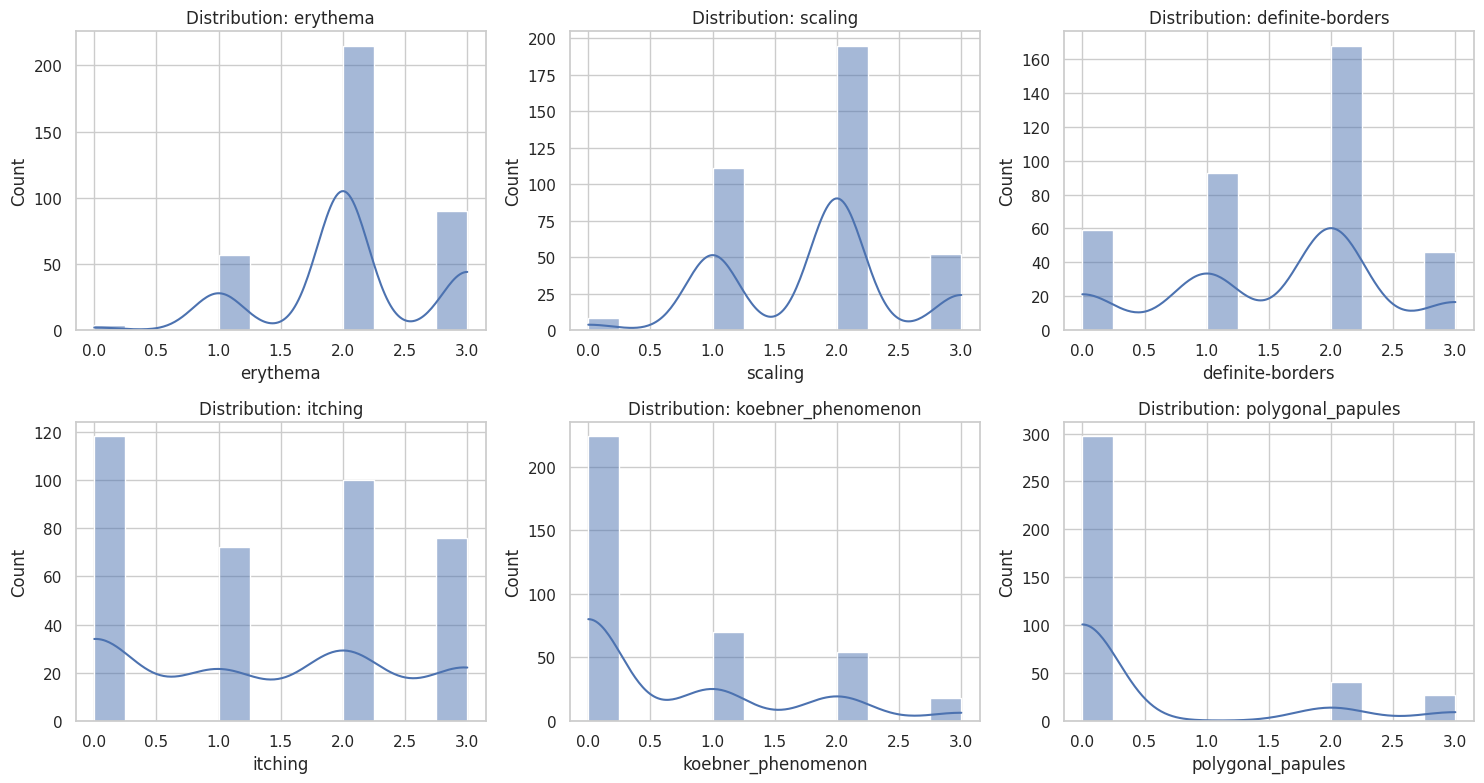

In [10]:

# 4. Key-feature distributions: histograms
key_features = list(X.columns[:6])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_features):
    sns.histplot(X[col], bins=12, kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()


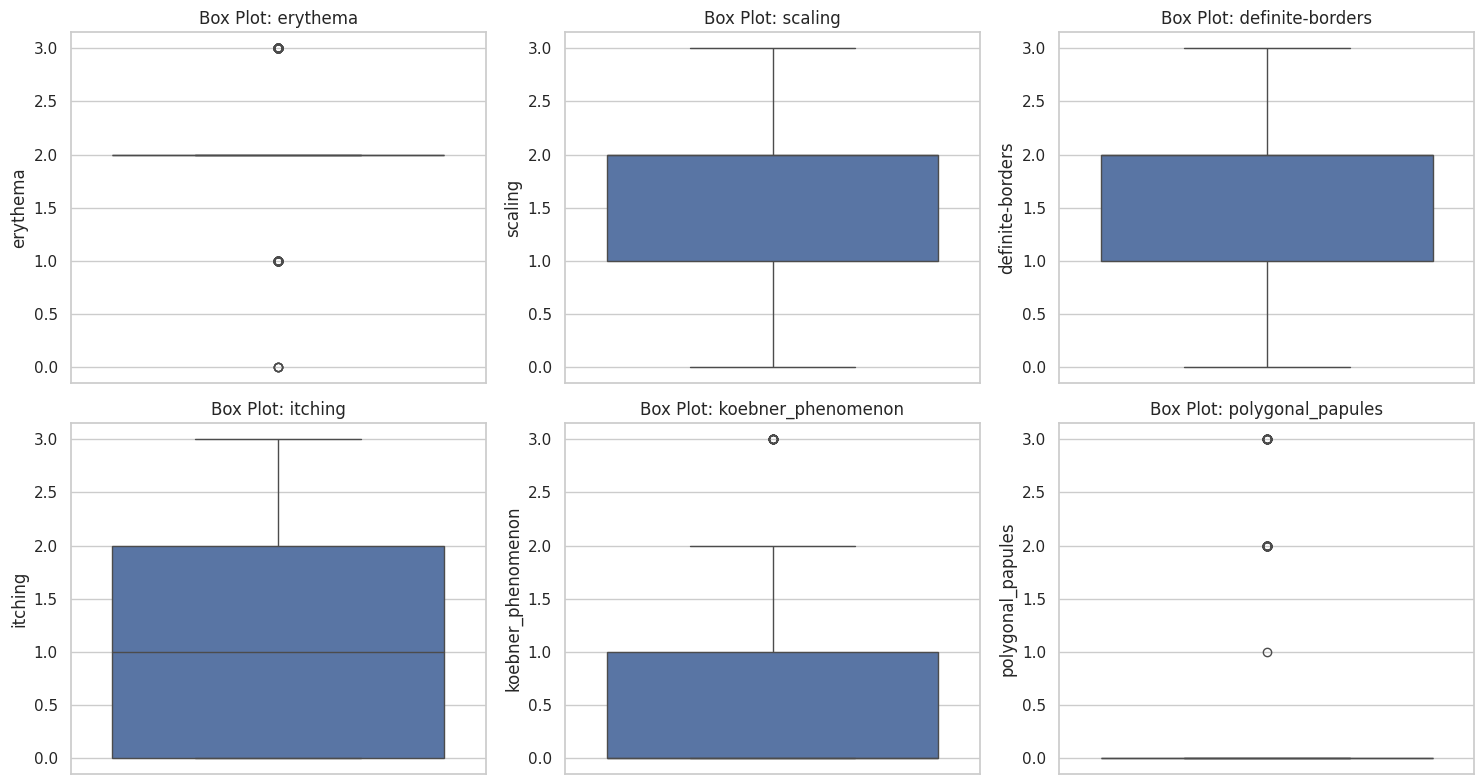

In [11]:

# Box plots for the same key features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_features):
    sns.boxplot(y=X[col], ax=ax)
    ax.set_title(f"Box Plot: {col}")
plt.tight_layout()
plt.show()


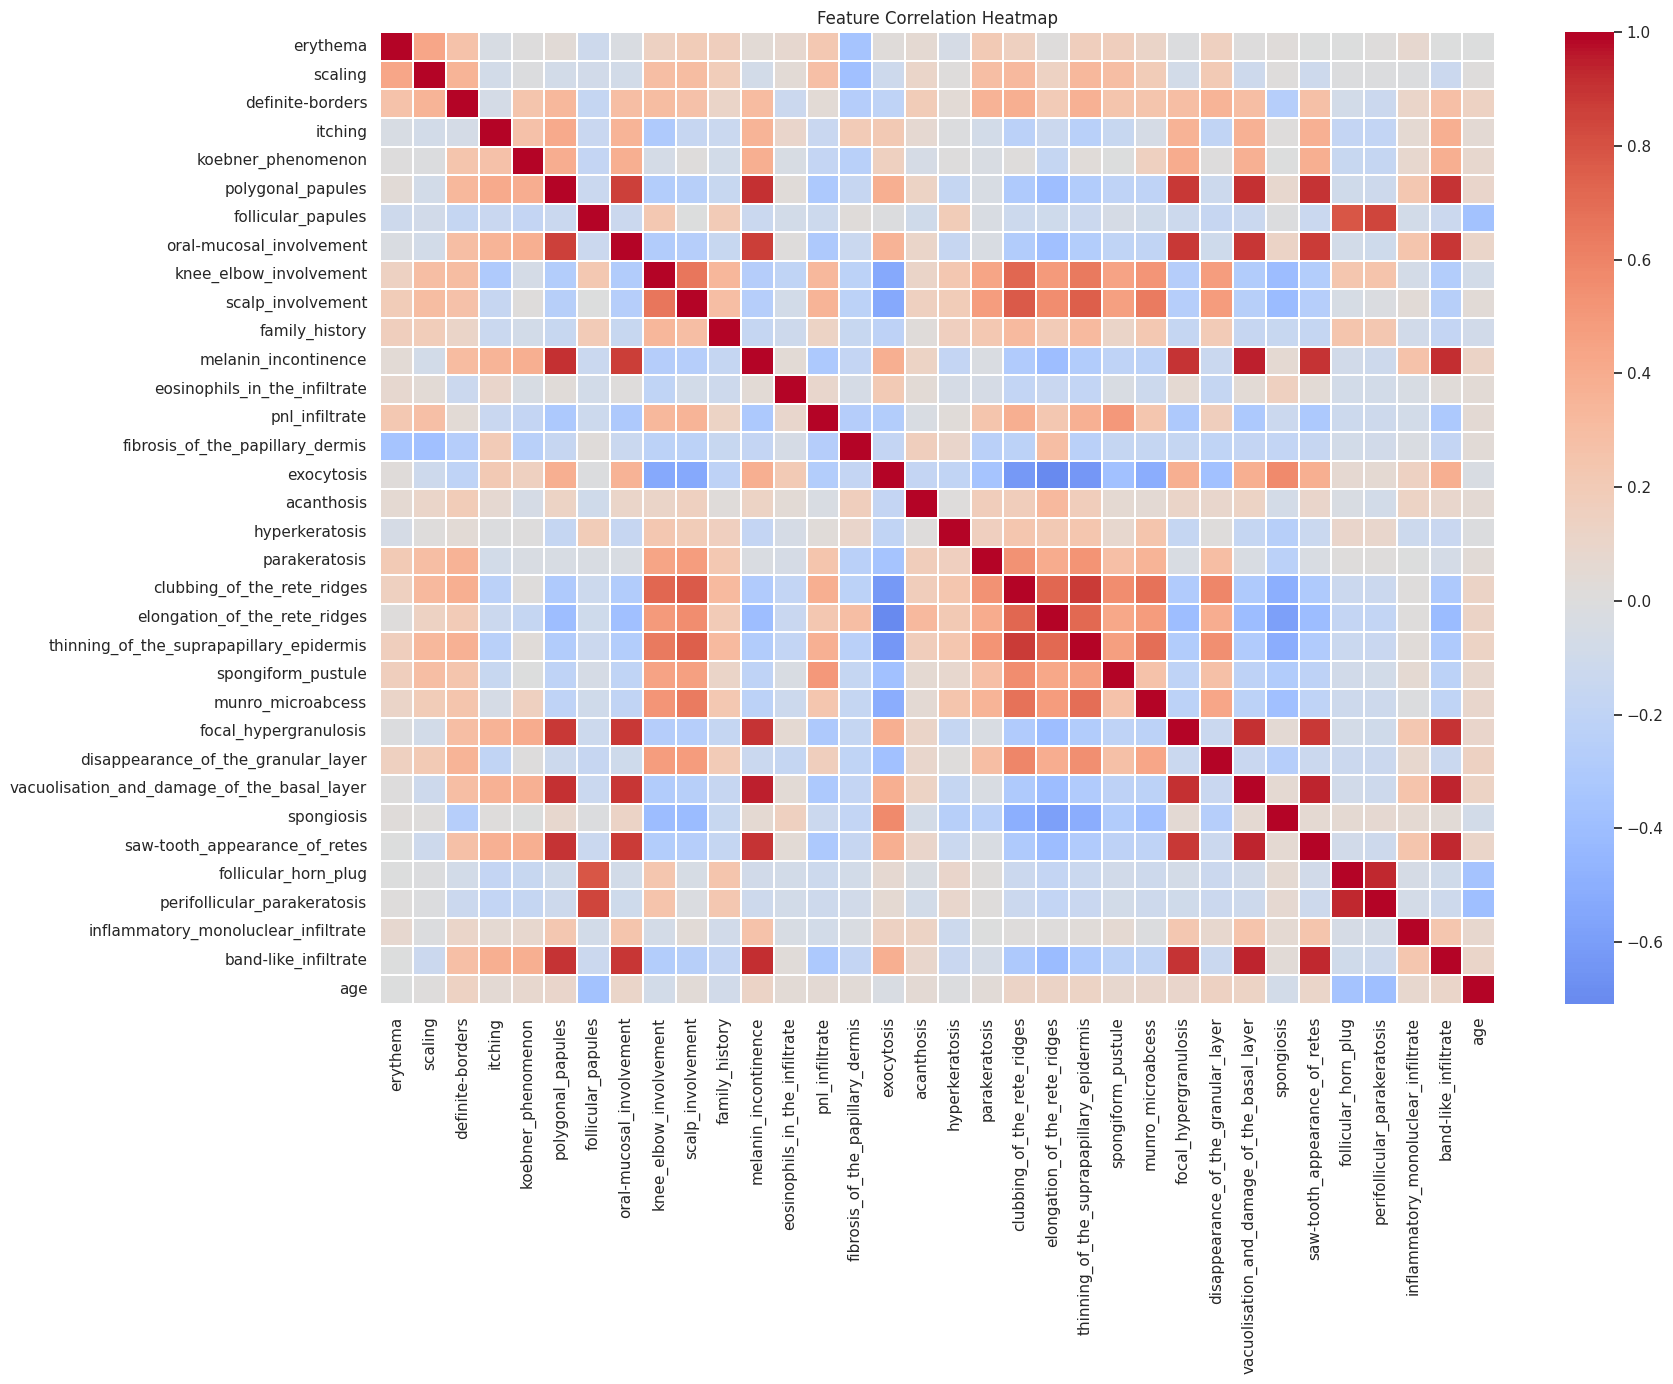

In [12]:

# Correlation heatmap
plt.figure(figsize=(18, 14))
corr = X.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


,Class,Disease,Count,Percentage
0,1,Psoriasis,112,30.60
1,2,Seboreic dermatitis,61,16.67
2,3,Lichen planus,72,19.67
3,4,Pityriasis rosea,49,13.39
4,5,Cronic dermatitis,52,14.21
5,6,Pityriasis rubra pilaris,20,5.46


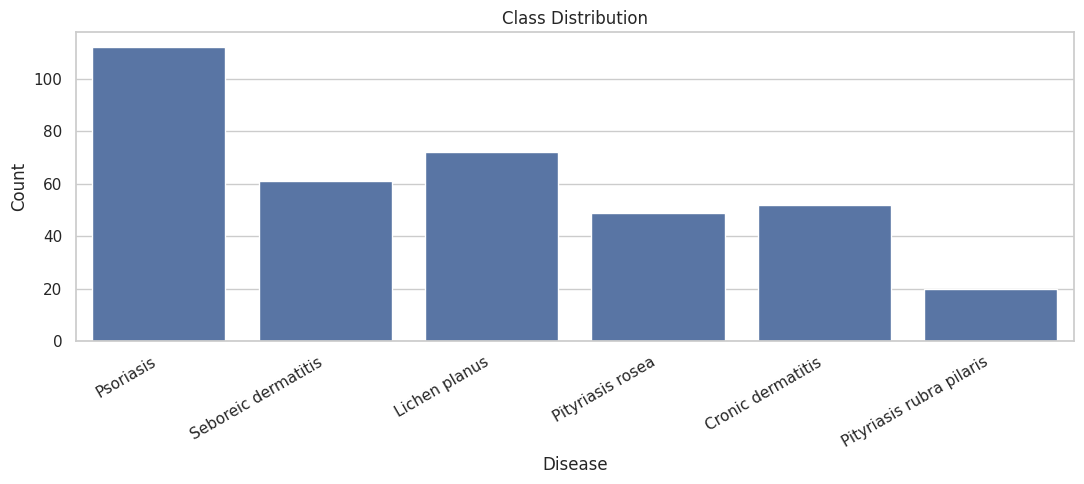

In [13]:

# Class distribution
class_names = {
    1: "Psoriasis",
    2: "Seboreic dermatitis",
    3: "Lichen planus",
    4: "Pityriasis rosea",
    5: "Cronic dermatitis",
    6: "Pityriasis rubra pilaris"
}

class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Disease": [class_names.get(i, str(i)) for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(y) * 100).round(2)
})

display(class_distribution)

plt.figure(figsize=(11, 5))
sns.barplot(data=class_distribution, x="Disease", y="Count")
plt.title("Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



### Class imbalance discussion

The class distribution is not perfectly balanced. In particular, some disease categories have substantially fewer observations than the largest class. This can cause a model to favor majority classes and can make overall accuracy look better than the model's performance on minority classes.

Therefore, this lab does not rely on accuracy alone. **Precision, recall, F1-score and multiclass ROC-AUC are also reported for every class**, and the train/test split is stratified.



# Task 2 – Data Preprocessing

Required steps:
1. Encode the target variable.
2. Split into training and testing sets using an **80/20 stratified split**.
3. Handle missing values and outliers without leaking information from the test set.
4. Standardize features so they are on a comparable scale.


In [14]:

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

encoded_to_original = dict(
    enumerate(label_encoder.inverse_transform(np.arange(len(label_encoder.classes_))))
)

print("Encoded classes:", label_encoder.classes_)
print("Mapping (encoded -> original class):", encoded_to_original)


Encoded classes: [1 2 3 4 5 6]
Mapping (encoded -> original class): {0: np.int64(1), 1: np.int64(2), 2: np.int64(3), 3: np.int64(4), 4: np.int64(5), 5: np.int64(6)}


In [15]:

# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining class proportions:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))

print("\nTesting class proportions:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(3))


Training samples: 292
Testing samples : 74

Training class proportions:
0    0.305
1    0.168
2    0.195
3    0.134
4    0.144
5    0.055
Name: proportion, dtype: float64

Testing class proportions:
0    0.311
1    0.162
2    0.203
3    0.135
4    0.135
5    0.054
Name: proportion, dtype: float64


In [16]:

# Median imputation + IQR clipping learned only from the training data
X_train_proc = X_train.copy()
X_test_proc = X_test.copy()

# Median values from training data only
medians = X_train_proc.median()
X_train_proc = X_train_proc.fillna(medians)
X_test_proc = X_test_proc.fillna(medians)

# IQR bounds from training data only
Q1 = X_train_proc.quantile(0.25)
Q3 = X_train_proc.quantile(0.75)
IQR = Q3 - Q1
lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

X_train_proc = X_train_proc.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
X_test_proc = X_test_proc.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

print("Remaining missing values in train:", X_train_proc.isna().sum().sum())
print("Remaining missing values in test :", X_test_proc.isna().sum().sum())


Remaining missing values in train: 0
Remaining missing values in test : 0


In [17]:

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_proc)
X_test_scaled = scaler.transform(X_test_proc)

print("Training mean after standardization (first 5 features):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

print("\nTraining standard deviation after standardization (first 5 features):")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))


Training mean after standardization (first 5 features):
[-0.  0. -0. -0.  0.]

Training standard deviation after standardization (first 5 features):
[1. 1. 1. 1. 1.]



# Task 3 – Model Training and Basic Evaluation

Four multiclass algorithms are implemented:

1. **K-Nearest Neighbors (KNN)**
2. **Logistic Regression (LR)**
3. **Random Forest (RF)**
4. **Support Vector Machine (SVM)**


The models are trained on the standardized training data and evaluated on the unseen test set.


In [25]:

# Define five multiclass models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(
        max_iter=3000, multi_class="auto", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "SVM": SVC(
        kernel="rbf", probability=True, class_weight="balanced",
        random_state=RANDOM_STATE

    )
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "ROC-AUC (Macro OvR)": roc_auc_score(
            y_test, y_prob, multi_class="ovr", average="macro"
        )
    })

results_df = pd.DataFrame(results).sort_values("F1 (Macro)", ascending=False)
display(results_df.round(4))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),ROC-AUC (Macro OvR)
3,SVM,0.9459,0.9417,0.9417,0.9394,0.9934
1,Logistic Regression,0.9459,0.9386,0.9389,0.9380,0.9925
0,KNN,0.9324,0.9294,0.9278,0.9246,0.9670
2,Random Forest,0.9189,0.9139,0.9194,0.9146,0.9919


In [26]:

# Per-class precision, recall and F1-score for EVERY model
for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)

    print("=" * 90)
    print(name)
    print("=" * 90)

    report = classification_report(
        y_test,
        y_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=[class_names.get(int(c), str(c)) for c in label_encoder.classes_],
        digits=4,
        zero_division=0
    )
    print(report)


KNN
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
     Seboreic dermatitis     0.8889    0.6667    0.7619        12
           Lichen planus     0.9375    1.0000    0.9677        15
        Pityriasis rosea     0.7500    0.9000    0.8182        10
       Cronic dermatitis     1.0000    1.0000    1.0000        10
Pityriasis rubra pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9324        74
               macro avg     0.9294    0.9278    0.9246        74
            weighted avg     0.9355    0.9324    0.9303        74

Logistic Regression
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
     Seboreic dermatitis     0.8333    0.8333    0.8333        12
           Lichen planus     1.0000    1.0000    1.0000        15
        Pityriasis rosea     0.8889    0.8000   

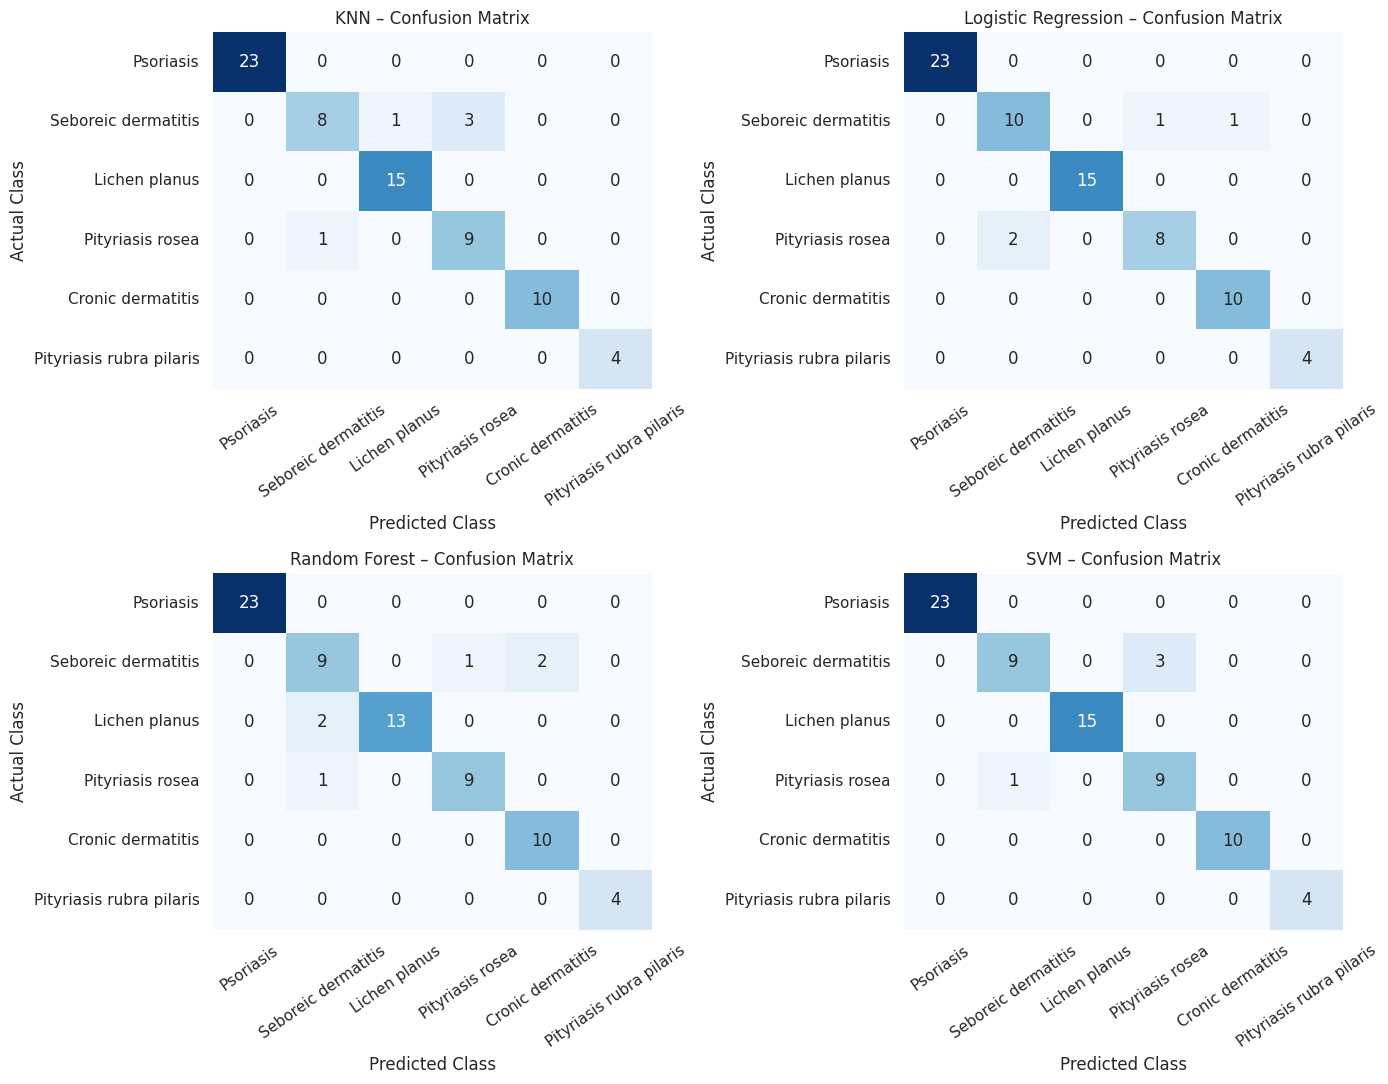

In [31]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

display_labels = [
    class_names.get(int(c), str(c)) for c in label_encoder.classes_
]

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_encoder.classes_)))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=display_labels, yticklabels=display_labels
    )
    ax.set_title(f"{name} – Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


## Multiclass ROC Curves and AUC

For multiclass classification, ROC is calculated using a **One-vs-Rest (OvR)** strategy: each disease class is treated as the positive class against all remaining classes.

For each model we report:
- ROC curve for every disease class.
- AUC for every disease class.
- Macro-average AUC across all six classes.

An AUC closer to 1 indicates better class discrimination, while 0.5 is approximately random discrimination.


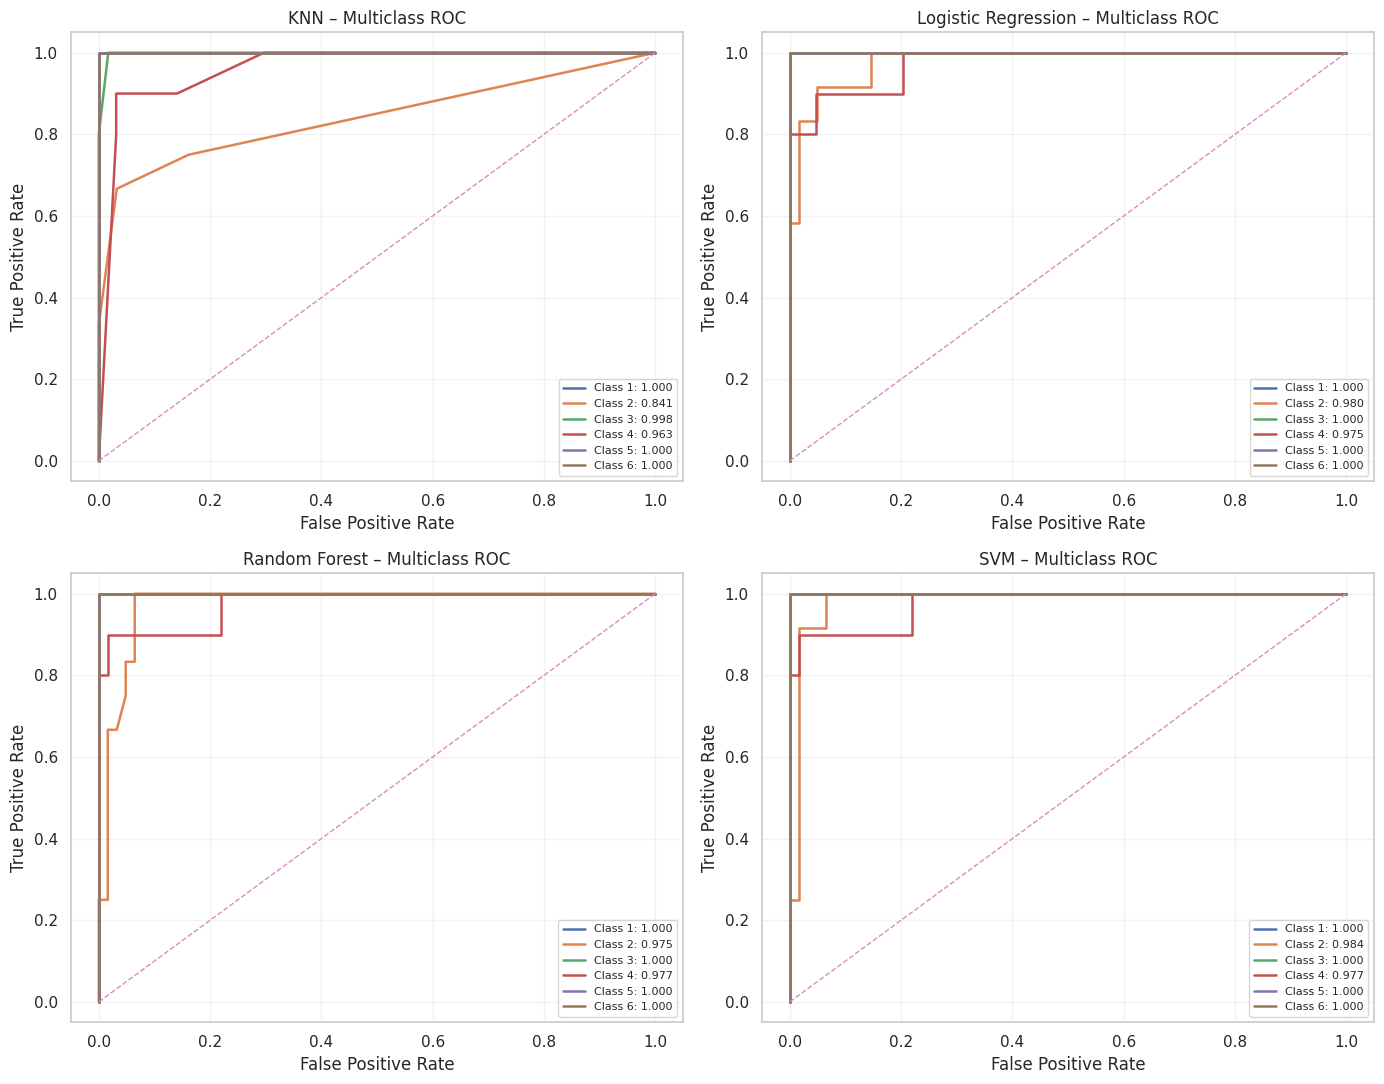

,Model,AUC Class 1,AUC Class 2,AUC Class 3,AUC Class 4,AUC Class 5,AUC Class 6,Macro AUC
0,KNN,1.0,0.8414,0.9983,0.9625,1.0,1.0,0.9670
1,Logistic Regression,1.0,0.9798,1.0000,0.9750,1.0,1.0,0.9925
2,Random Forest,1.0,0.9751,1.0000,0.9766,1.0,1.0,0.9919
3,SVM,1.0,0.9839,1.0000,0.9766,1.0,1.0,0.9934


In [32]:
# ROC curves and per-class AUC for every model
n_classes = len(label_encoder.classes_
)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

auc_rows = []

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_prob = model.predict_proba(X_test_scaled)

    class_aucs = []
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        class_auc = auc(fpr, tpr)
        class_aucs.append(class_auc)

        ax.plot(
            fpr, tpr, linewidth=1.8,
            label=f"Class {i+1}: {class_auc:.3f}"
        )

    macro_auc = roc_auc_score(
        y_test, y_prob, multi_class="ovr", average="macro"
    )

    auc_rows.append({
        "Model": name,
        **{f"AUC Class {i+1}": class_aucs[i] for i in range(n_classes)},
        "Macro AUC": macro_auc
    })

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"{name} – Multiclass ROC")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

auc_df = pd.DataFrame(auc_rows)
display(auc_df.round(4))

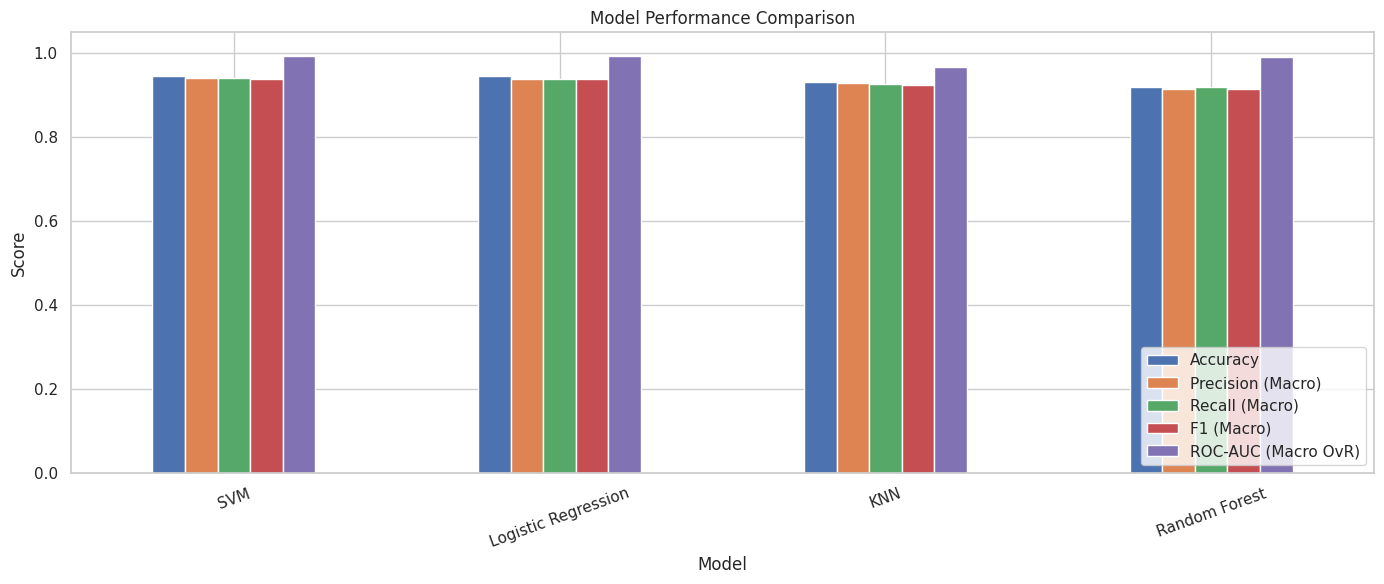

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),ROC-AUC (Macro OvR)
3,SVM,0.9459,0.9417,0.9417,0.9394,0.9934
1,Logistic Regression,0.9459,0.9386,0.9389,0.9380,0.9925
0,KNN,0.9324,0.9294,0.9278,0.9246,0.9670
2,Random Forest,0.9189,0.9139,0.9194,0.9146,0.9919


In [29]:

# Overall comparison of all models
comparison = results_df.copy()

comparison_plot = comparison.set_index("Model")[
    ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 (Macro)", "ROC-AUC (Macro OvR)"]
]

ax = comparison_plot.plot(kind="bar", figsize=(14, 6))
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(comparison.round(4))


In [30]:

# Select the best model using macro F1-score
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Best model based on macro F1-score:", best_model_name)

best_pred = best_model.predict(X_test_scaled)
print("\nDetailed classification report for the best model:")
print(classification_report(
    y_test,
    best_pred,
    labels=np.arange(n_classes),
    target_names=display_labels,
    digits=4,
    zero_division=0
))


Best model based on macro F1-score: SVM

Detailed classification report for the best model:
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
     Seboreic dermatitis     0.9000    0.7500    0.8182        12
           Lichen planus     1.0000    1.0000    1.0000        15
        Pityriasis rosea     0.7500    0.9000    0.8182        10
       Cronic dermatitis     1.0000    1.0000    1.0000        10
Pityriasis rubra pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9459        74
               macro avg     0.9417    0.9417    0.9394        74
            weighted avg     0.9500    0.9459    0.9459        74




# Interpretation of Results

### 1. Data exploration
The Dermatology dataset is a multiclass medical classification problem with six disease classes. Summary statistics, missing-value checks, duplicate checks, outlier detection, histograms, box plots, correlation analysis, and class distribution are included above.

### 2. Preprocessing
The target is label-encoded, the dataset is split using an 80/20 **stratified** split, missing feature values are filled using training-set medians, extreme values are capped using training-set IQR limits, and all features are standardized.

### 3. Model comparison
Five different algorithms are compared. **Accuracy** gives overall correctness, while macro precision, macro recall and macro F1 give equal importance to every disease class. This is especially useful when class sizes differ.

### 4. Confusion matrices
A confusion matrix shows which disease classes are being confused with one another. Large diagonal values indicate correct predictions; off-diagonal values show misclassification between diseases.

### 5. ROC/AUC
Because this is multiclass classification, ROC-AUC is calculated with a One-vs-Rest strategy. Higher AUC means better separation between a particular disease and the remaining diseases.

### 6. Final model
The notebook selects the model with the highest **macro F1-score** as the best overall model. This criterion is preferable to selecting solely by accuracy when the classes are not perfectly balanced.

### 7. Healthcare interpretation
These models are educational demonstrations of multiclass classification and should not be treated as clinical diagnostic systems. A real healthcare deployment would require external validation, clinical review, robust handling of missing/uncertain observations, calibration, fairness analysis, and regulatory/clinical approval.
